In [63]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main_human_capital import ModelClass, constraints

from scipy.optimize import minimize
from scipy.optimize import LinearConstraint

from IPython.display import display, Math

from plots import plot_series

model = ModelClass()

par = model.par
sol = model.sol
sim = model.sim

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


This model is used to find a certain condition. Currently, I just minimize the change in average wage level, because it was not easy to get by just setting parameters.

In [68]:
param_spec = {
    "Q_a_shape": {"value": par.Q_a_shape, "bounds": (0.00001, 0.1), "active": True},
    "phi":   {"value": par.phi,  "bounds": (0.01, 0.99),  "active": True},
    "alpha":    {"value": par.alpha,  "bounds": (0.01, 0.99),  "active": True},
    "mu":     {"value": par.mu,  "bounds": (1.0, 10.0), "active": True},
    "c":        {"value": par.c,  "bounds": (0.1, 1000.0),  "active": True},
}


active_names = [k for k, v in param_spec.items() if v["active"]]
x0 = np.array([param_spec[k]["value"] for k in active_names], dtype=float)
bounds = [param_spec[k]["bounds"] for k in active_names]

def apply_params(par, names, values):
    for name, val in zip(names, values):
        setattr(par, name, float(val))
    return par

def objective(x):
    # Initialize all non-active parameters to their default values
    model.setup()

    for name, spec in param_spec.items():
        if not spec["active"]:
            setattr(par, name, spec["value"])

    model.update_params()

    apply_params(par, active_names, x)

    model.solve(do_print=False)

    model.simulate_transition()

    wage_gap_sim = (
        np.average(model.sim.avg_wage[:, -5::] / model.sim.avg_wage[0, -5::], axis=1)
        - np.average(model.sim.avg_wage[:, :5] / model.sim.avg_wage[0, :5], axis=1)
    ) * 100

    wage_gap_data = np.loadtxt('Exogenous_estimation/wage_gap_data_mock.csv', delimiter=',')[1:]

    SSE = np.sum((wage_gap_sim - wage_gap_data)**2)

    # print(list(x), SSE )

    return SSE


def optimize_and_plot(single_run=True, optimizer_trials=2):
    runs = []

    n_runs = 1 if single_run else optimizer_trials

    for i in range(n_runs):
        x0_random = np.array([np.random.uniform(low, high) for (low, high) in bounds], dtype=float)

        result = minimize(
            objective,
            x0=x0_random,
            bounds=bounds,
            method="Nelder-Mead",
            options={'maxiter': 20000, 'disp': False}
        )

        runs.append(result)

        print(list(result.x), result.fun)

    model.setup()

    result = min(runs, key=lambda r: r.fun)

    optimized_values = result.x
    apply_params(par, active_names, optimized_values)

    model.update_params()

    print("Success:", result.success)
    print("Message:", result.message)
    print("Objective value:", result.fun)
    print("Optimized parameters:")
    for name in active_names:
        print("par." + name + " = ", getattr(par, name))

    
    model.solve()
    model.simulate_transition()

    wage_gap = (
        np.average(model.sim.avg_wage[:, -5::] / model.sim.avg_wage[0, -5::], axis=1)
        - np.average(model.sim.avg_wage[:, :5] / model.sim.avg_wage[0, :5], axis=1)
    ) * 100

    plot_series(wage_gap, title="Wage Gap across Cohorts", ylabel="Wage Gap (%)")

    return runs, optimized_values

runs, optimized_values = optimize_and_plot(single_run=False, optimizer_trials=100)

[0.04848779186766512, 0.99, 0.08859508798618759, 9.999999999363578, 66.59018543708844] 5342.08350090151
[0.1, 0.99, 0.08657341378380337, 9.999933903166767, 70.9794274255168] 5341.650535780316


c:\Users\peter\Documents\GitHub\Danish-Wage-Gap-Model\main_human_capital.py:392: RuntimeWarning: divide by zero encountered in scalar power
  return (1 - par.alpha)*(Ll)**(par.alpha)*(Lh)**(- par.alpha)


[0.1, 0.6824711762001887, 0.01, 1.0, 1000.0] 7049.606943020669
[1.0000000000000751e-05, 0.6047368245375859, 0.010000160988122363, 1.7850230084787713, 19.128953039066374] 7288.081780002249
[0.01823839373058954, 0.599307362882971, 0.01, 4.838699958701605, 19.126783775699558] 7288.095451364341
[0.0995345472305757, 0.6513152482854542, 0.3018942361267746, 7.674311441099045, 191.70939718408889] 7358.079689547681
[0.0032863969344594504, 0.7021437647983715, 0.05443344767752661, 1.0, 940.2646164401383] 7056.201575049577
[0.0022144267441006546, 0.6504529306604694, 0.021620856560862337, 1.0019366024390275, 129.6198423207326] 7174.67948370152
[0.09584033569685822, 0.99, 0.048312066415089866, 1.0, 545.9107960090164] 5226.326899441255
[1.0000000000000006e-05, 0.6070586063586267, 0.01040539607057787, 9.822942679321457, 8.10181581724516] 7287.224983484765
[1.0000000000000006e-05, 0.6872246721829207, 0.8941664320551301, 1.0, 0.10000000000000009] 7537.614831557921


KeyboardInterrupt: 

In [62]:
par.phi

0.8590557160627587

par.Q_a_shape =  0.001972980040464264
par.phi =  0.8590557160627587
par.alpha =  0.8274843751517558
par.mu =  2.0
par.c =  100.39438051715202
7544.961884237089


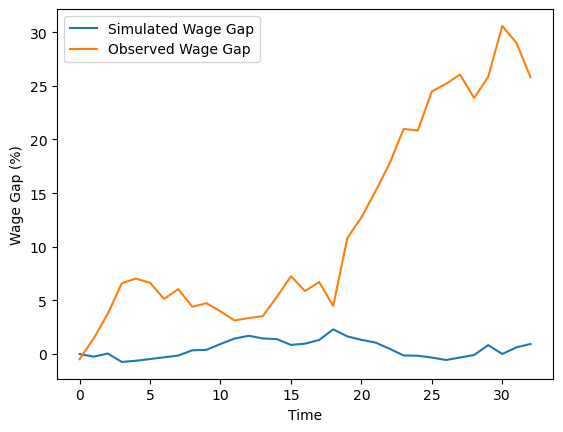

In [60]:
model.setup()

# optimized_values = [np.float64(0.623961436054632), np.float64(0.383503115066401), np.float64(10.0), np.float64(84.00874005478093)]
optimized_values = [np.float64(0.001972980040464264), np.float64(0.8590557160627587), np.float64(0.8274843751517558), np.float64(2.0), np.float64(100.39438051715201444)]

apply_params(par, active_names, optimized_values)

for name in active_names:
    print("par." + name + " = ", getattr(par, name))

model.solve()
model.simulate_transition()

groups = 5

wage_gap = (
    np.average(model.sim.avg_wage[:, -groups::] / model.sim.avg_wage[0, -groups::], axis=1)
    - np.average(model.sim.avg_wage[:, :groups] / model.sim.avg_wage[0, :groups], axis=1)
) * 100

data = np.loadtxt('Exogenous_estimation/wage_gap_data_mock.csv', delimiter=',')[1:]

print(np.sum((wage_gap - data)**2))

plt.plot(wage_gap, label='Simulated Wage Gap')
plt.plot(data, label='Observed Wage Gap')
plt.xlabel('Time')
plt.ylabel('Wage Gap (%)')
plt.legend()
plt.show()

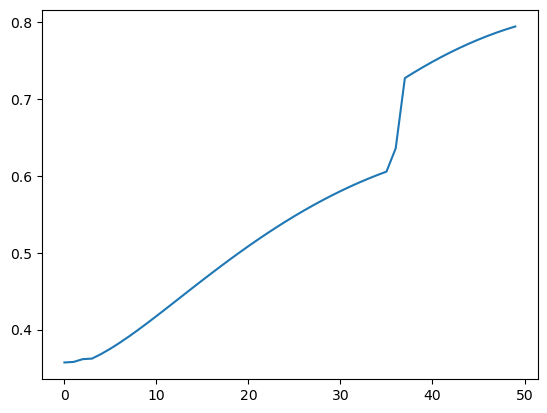

In [57]:
plt.plot(model.sim.avg_wage[1, :])

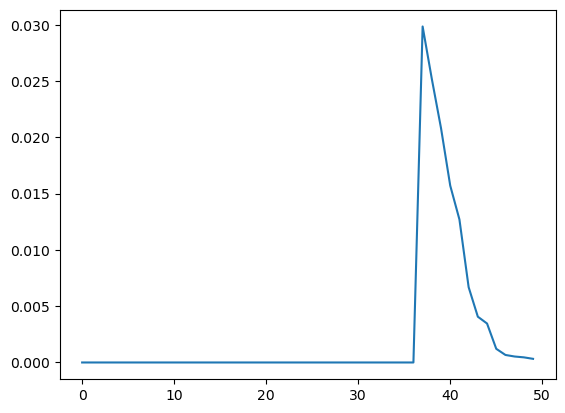

In [58]:
plt.plot(model.sim.l_h[0, :])

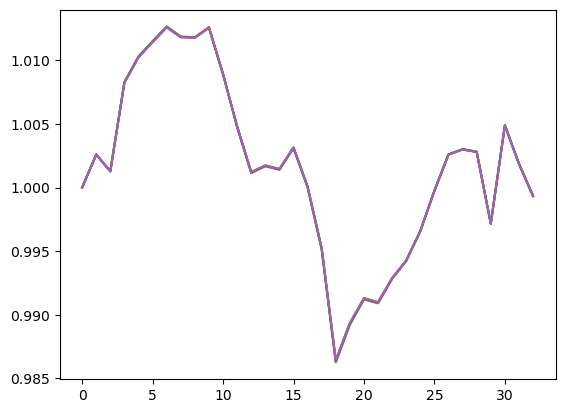

In [34]:
plt.plot(model.sim.avg_wage[:, -5::] / model.sim.avg_wage[0, -5::])

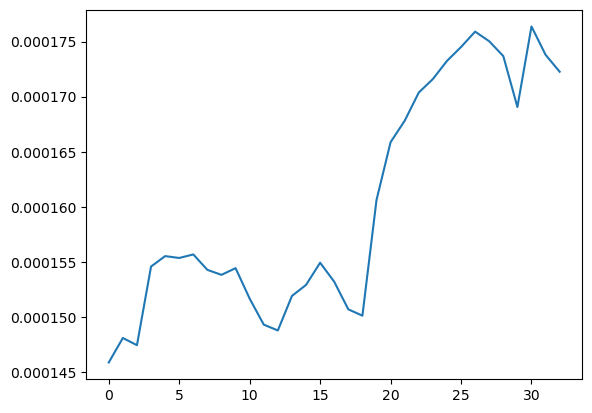

In [45]:
plt.plot(model.sim.avg_wage[:, -1])

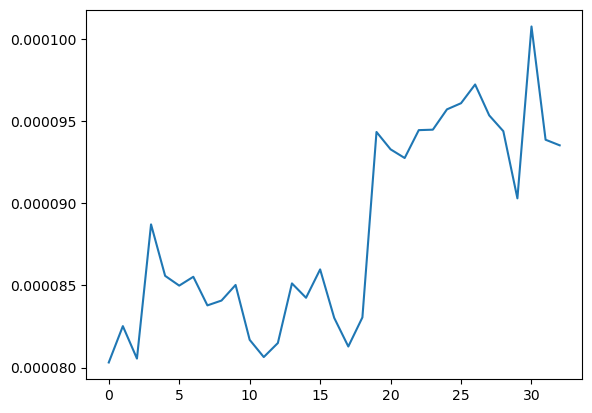

In [46]:
plt.plot(model.sim.avg_wage[:, 0])

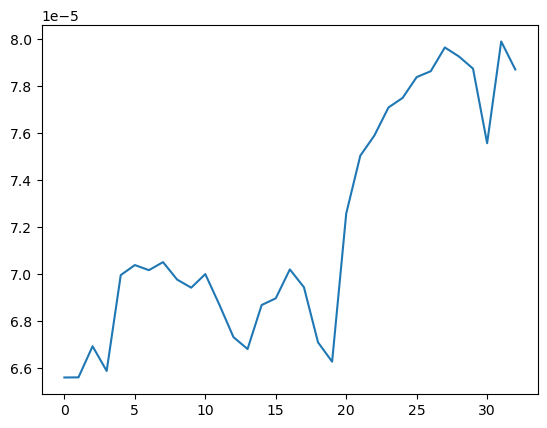

In [37]:
plt.plot(model.sim.avg_wage[:, -1] - model.sim.avg_wage[:, 0], label='Simulated Wage Gap')

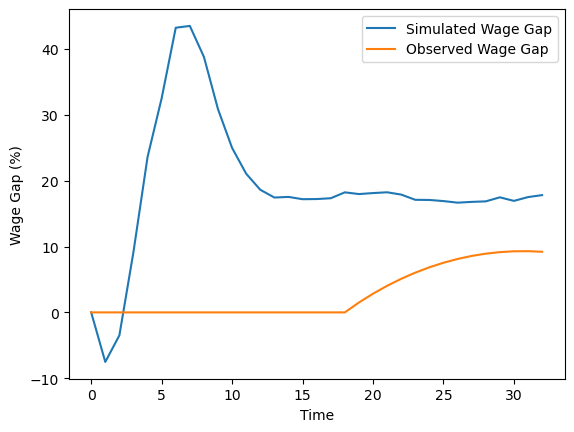